In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

# Import des données

In [5]:
# Tableau : Ne-HCN
Ne = np.genfromtxt("Data/Ne-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Conversion des µEh en mEh
energy_mEh = Ne['Energy'] * 1e-3
# Ajout de la colonne en Eh
Ne = rfn.append_fields(Ne, names='Energy_mEh', data=energy_mEh, usemask=False)

# Parametres donnés par Toczylowski
params_Ne = np.array([ 1.39799,   0.06304,   0.10472,   0.10103,   0.04239, -0.00674,  # b
                      -33692.705,-209959.32,-16394.597,-107262.52,                     # c
                       13.60561,  0.87434,   2.39464,   0.60195,   0.31713,  0.05930,  # d
                       0.10500,  -0.06621,  -0.05328,   0.01479,   0.00609, -0.00197,  # g0
                      -0.03368,   0.02788,   0.02191,  -0.00483,  -0.00308,  0.00011,  # g1
                       0.00374,  -0.00401,  -0.00298,   0.00070,   0.00054,  0.00004,  # g2
                      -0.000154,  0.000203,  0.000141, -0.000046, -0.000033,-0.000002])# g3

# Implémentation des fonctions

In [6]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [36]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [8]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [24]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [25]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [9]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [10]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## Calculs

In [11]:
R = np.asarray(Ne["R"], dtype=float)
Theta = np.asarray(Ne["Theta"], dtype=float)
V_table = np.asarray(Ne["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((151,), (151,), (151,))

In [39]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ne, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ne, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [33]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.3830486073554134, 0.06663105510151375, 0.10698625699712737, 0.09760088214660011, 0.04705650552039718, -0.02196574193195195]
[c0,c1,c2,c3]             = [-33692.704993054394, -209959.31998213768, -16394.59701900361, -107262.52002793267]
[d0,d1,d2,d3,d4,d5]       = [13.602267914215487, 0.5712203228185608, 2.2464870938120223, 0.5454987388397787, 0.3331073691379873, -0.02000804982237705]
[g00,g01,g02,g03,g04,g05] = [0.09492724664467724, -0.038425458202877016, -0.04708031291314257, 0.004636526940900704, 0.005707843765591734, 0.003098993200649454]
[g10,g11,g12,g13,g14,g15] = [-0.029935230323578782, 0.019419862246296042, 0.021591161979383405, 0.0002413698341214693, -0.002665033268667819, -0.0019046300602476487]
[g20,g21,g22,g23,g24,g25] = [0.0032334425229150004, -0.0030932886221003097, -0.00313837864646431, -0.00010121856825079068, 0.0004998108482700484, 0.00032473780227877333]
[g30,g31,g32,g33,g34,g35] = [-0.00012826420463864837, 0.00016476594684792728, 0.00015

In [34]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 1.38304861e+00  6.66310551e-02  1.06986257e-01  9.76008821e-02
  4.70565055e-02 -2.19657419e-02 -3.36927050e+04 -2.09959320e+05
 -1.63945970e+04 -1.07262520e+05  1.36022679e+01  5.71220323e-01
  2.24648709e+00  5.45498739e-01  3.33107369e-01 -2.00080498e-02
  9.49272466e-02 -3.84254582e-02 -4.70803129e-02  4.63652694e-03
  5.70784377e-03  3.09899320e-03 -2.99352303e-02  1.94198622e-02
  2.15911620e-02  2.41369834e-04 -2.66503327e-03 -1.90463006e-03
  3.23344252e-03 -3.09328862e-03 -3.13837865e-03 -1.01218568e-04
  4.99810848e-04  3.24737802e-04 -1.28264205e-04  1.64765947e-04
  1.53313190e-04 -3.08610053e-06 -3.34215166e-05 -1.59917815e-05]
[ 1.31122375e+00 -7.77337269e-02  2.84989915e-02  1.09661726e-01
  1.56867477e-02 -7.95843658e-03 -3.00908153e+04 -2.10622318e+05
 -1.32332759e+04 -1.06660954e+05  1.32715242e+01 -6.85954489e-01
  1.69983540e+00  7.26679264e-01  1.48967515e-01  3.35420563e-02
  1.24416306e-01  7.32280330e-02  1.99426454e-02  1.00388709e-02
  1.63285012e-02  9.0356

In [40]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_Ne, R, Theta)

r2_cf = rsq(V_table, V_pred_cf)
r2_cf_sigma = rsq(V_table, V_pred_cf_sigma)
r2_params_these = rsq(V_table, V_params_these)

rmse_cf = rmse(V_table, V_pred_cf)
rmse_cf_sigma = rmse(V_table, V_pred_cf_sigma)
rmse_params_these = rmse(V_table, V_params_these)

mae_cf = mae(V_table, V_pred_cf)
mae_cf_sigma = mae(V_table, V_pred_cf_sigma)
mae_params_these = mae(V_table, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999999535540615
R² (avec sigma=y)       : 0.9999916454245402
R² (paramètres these)   : 0.9992698330368525

rmse (sans sigma)       : 0.0005543392662505258
rmse (avec sigma=y)     : 0.0074347088158331414
rmse (paramètres these) : 0.06950448990705554

mae (sans sigma)        : 0.00042756114002993775
mae (avec sigma=y)      : 0.002093845882751144
mae (paramètres these)  : 0.027594551913241342


### Affichage des résultats

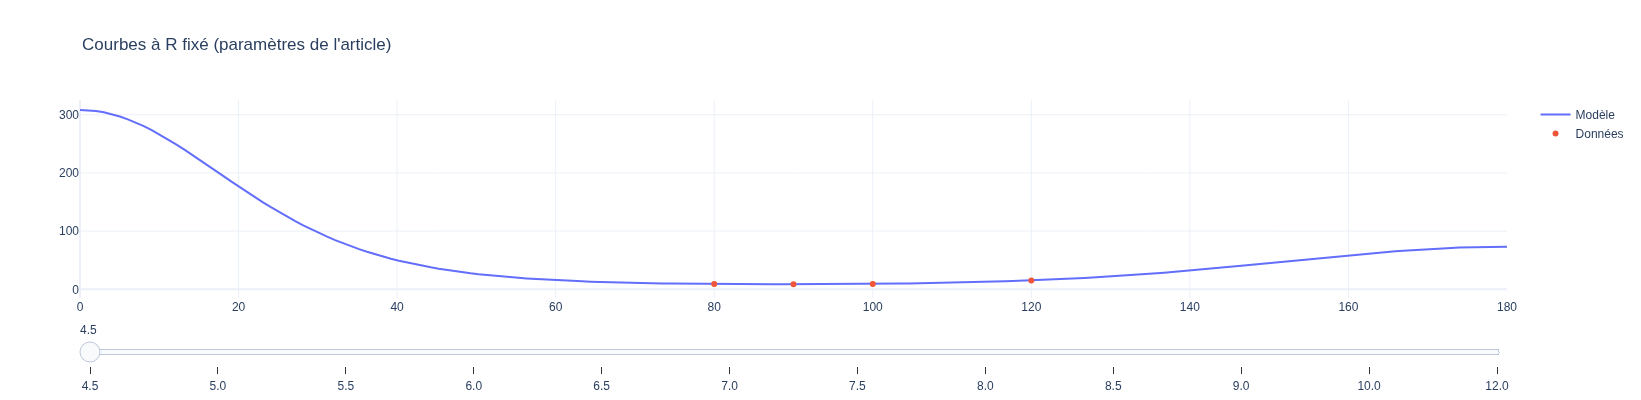

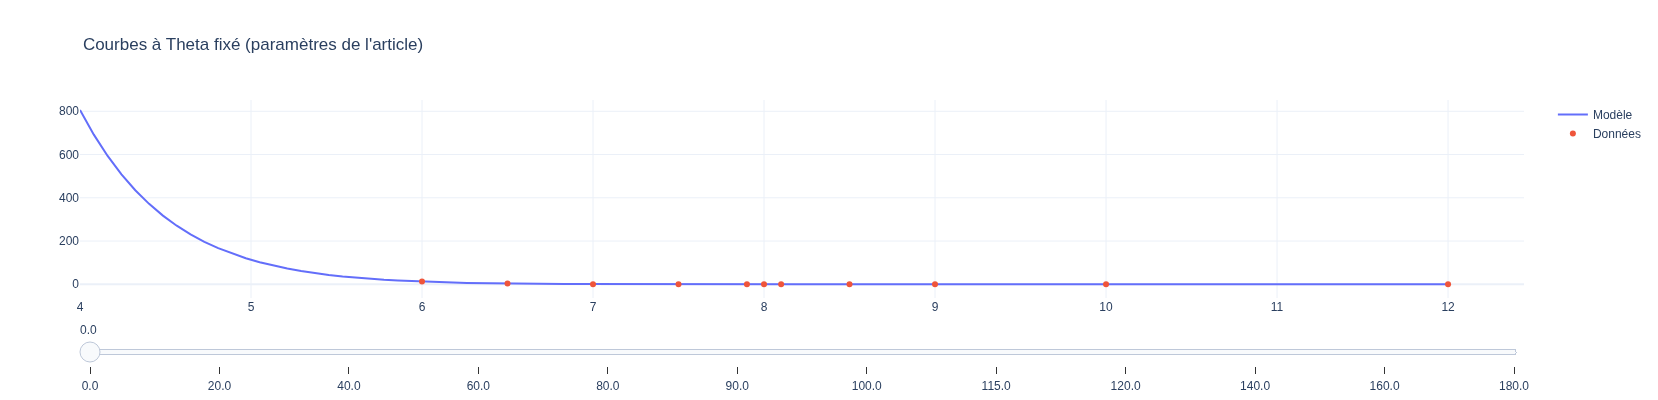

In [16]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_Ne, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_Ne, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

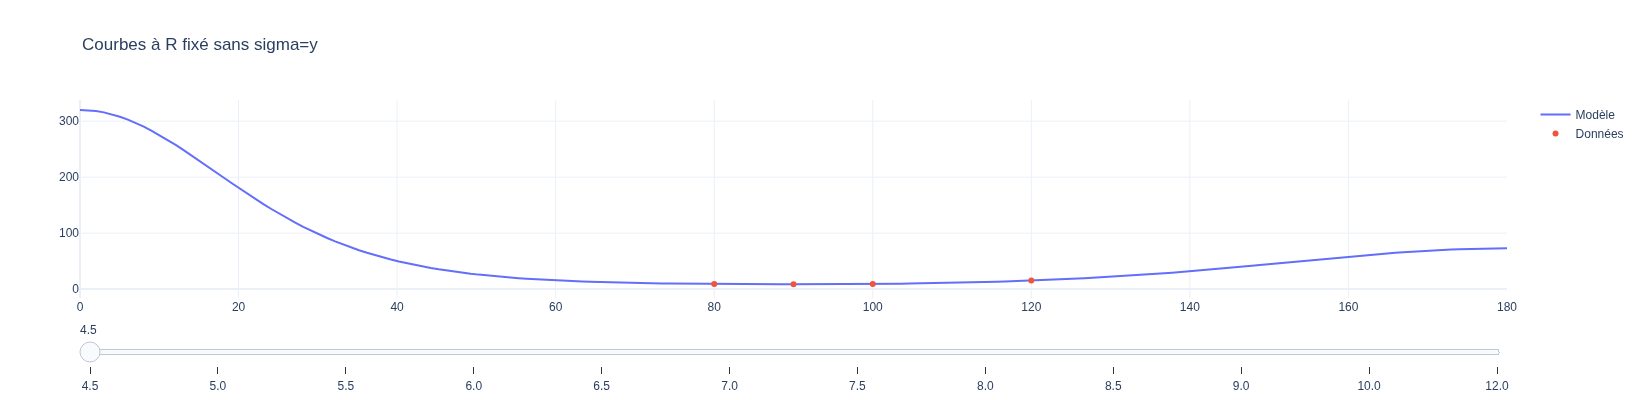

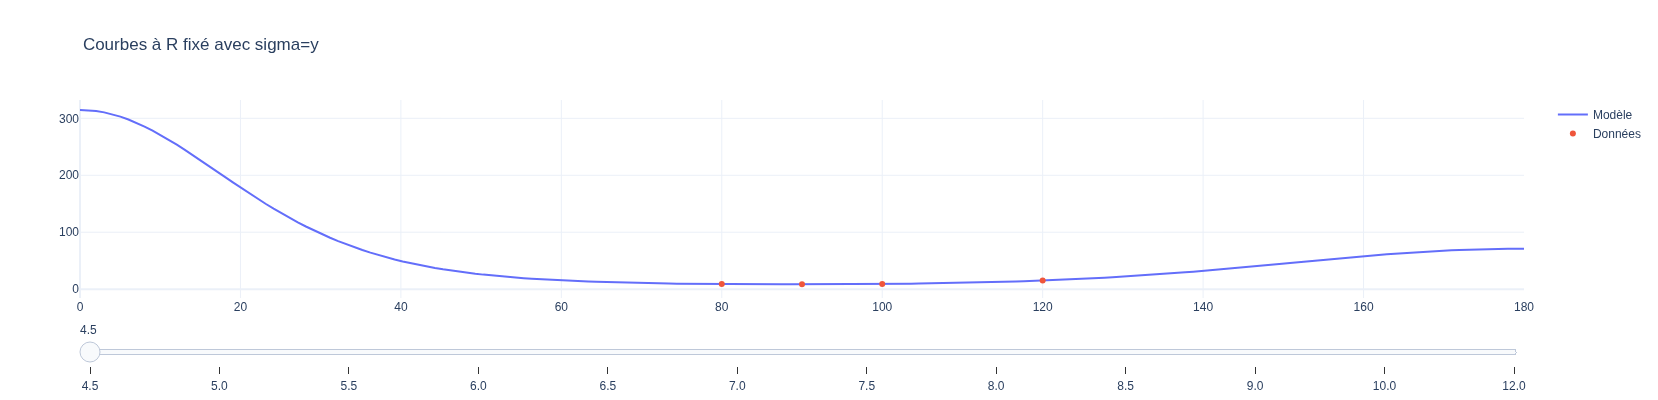

In [17]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

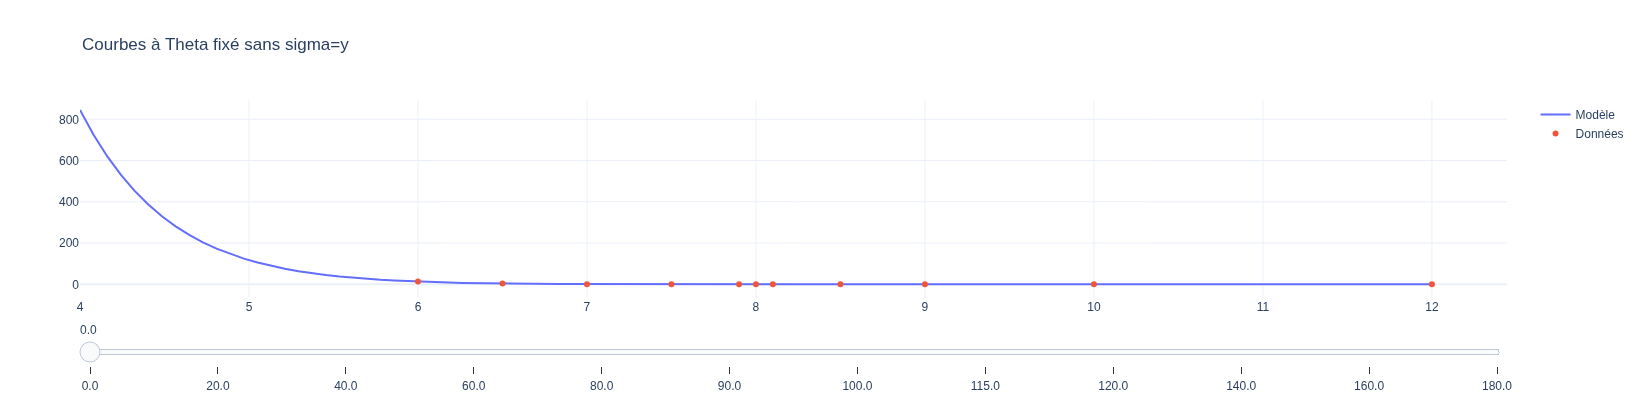

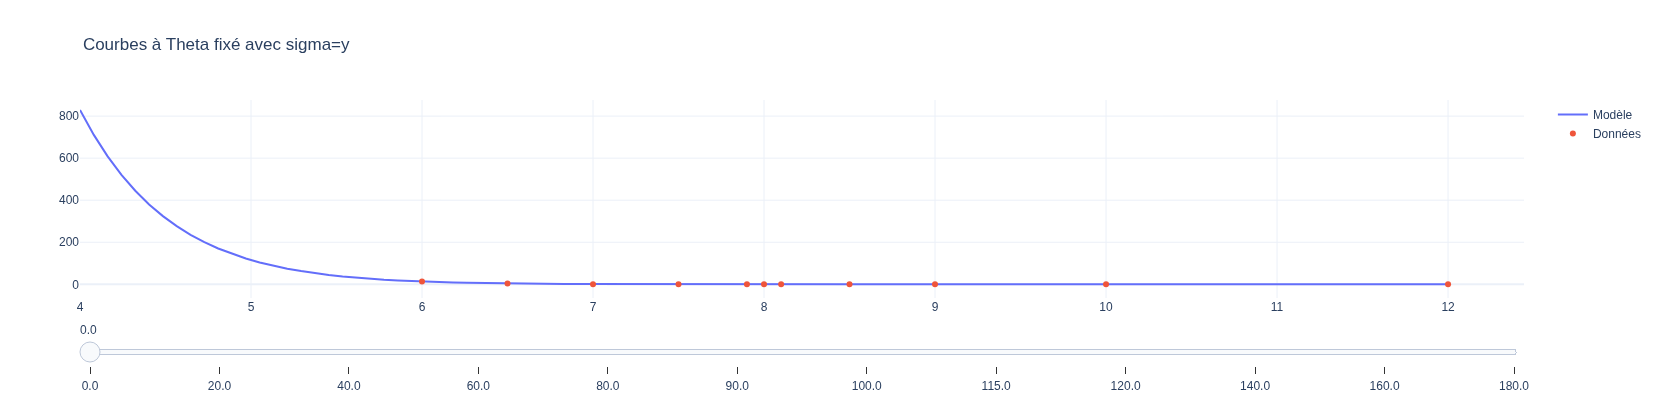

In [18]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

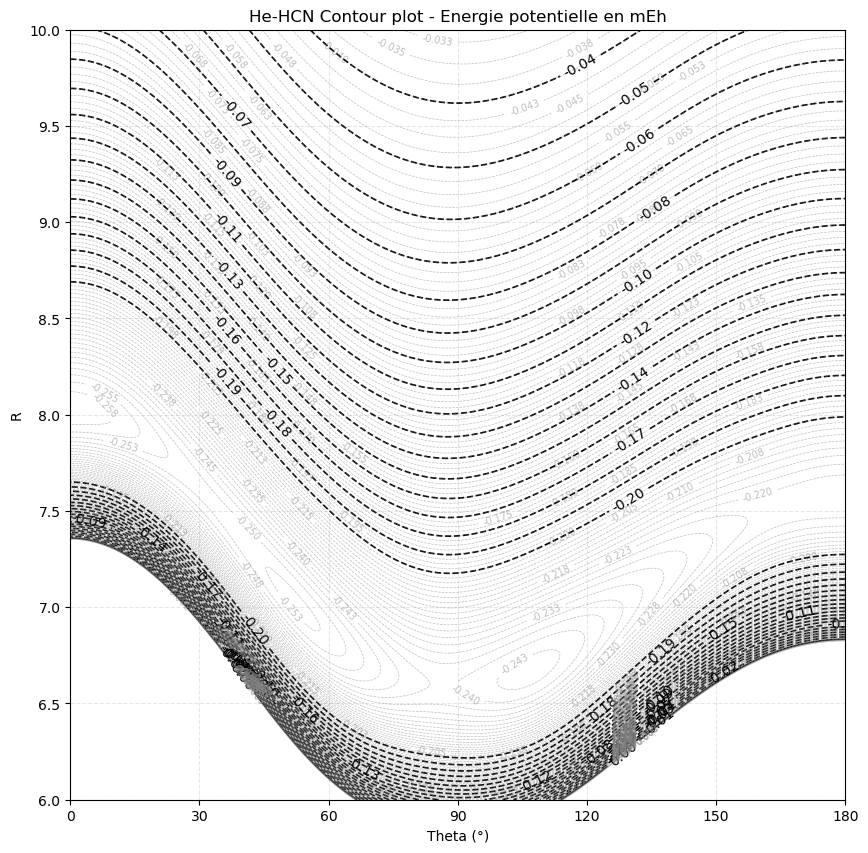

In [19]:
# Definition des axes
theta_grid = np.linspace(0, 180, 250)
r_grid = np.linspace(6, 10, 250)
Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)

# Calcul de la matrice d'energie Z
Z = np.array([
    V_opt(params_opt_cf_sigma, np.full_like(theta_grid, r), theta_grid)
    for r in r_grid
])

# Masquage des contours en dessous de R=7.2 pour Theta proche de 0
mask_repulsion = (R_mesh < 7.2) & (Theta_mesh < 10)
Z_masked = Z.copy()
Z_masked[mask_repulsion] = np.nan

# Niveaux contours principaux
levels_main = np.arange(-0.2, 0.001, 0.01)

# Niveaux contours secondaires
levels_fine = np.arange(-1, 0.01, 0.0025)


plt.figure(figsize=(10, 10))

# Contours principaux en noir
cp_main = plt.contour(Theta_mesh, R_mesh, Z_masked, levels=levels_main, colors='black', linewidths=1.2)
plt.clabel(cp_main, inline=True, fontsize=10, fmt='%.2f')

# Ajout de lignes de fond plus fines pour la structure
cp_fine = plt.contour(Theta_mesh, R_mesh, Z_masked, levels=levels_fine, colors='gray', alpha=0.5, linewidths=0.5)
plt.clabel(cp_fine, inline=True, fontsize=7, fmt='%.3f')

plt.title("He-HCN Contour plot - Energie potentielle en mEh")
plt.xlabel("Theta (°)")
plt.ylabel("R")

# Ajout de ticks pour l'axe R
plt.yticks(np.arange(6, 10.5, 0.5))
plt.xticks(np.arange(0, 181, 30))

plt.grid(True, linestyle='--', alpha=0.3)